In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np 
import pandas as pd 
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords as stopwords_scratch

[nltk_data] Downloading package stopwords to C:\Users\Yohanes
[nltk_data]     Joni\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [3]:
data = pd.read_csv('data/bitcoin2_clean.csv')
data

,full_text
0,cathie wood says smart investors need to start...
1,bitcoin block growth gives the nft a living ...
2,yeah this trend has been going on for a while...
3,you can go back in time and meet your self\n\...
4,fiat supply can expand\nbitcoin supply cannot\...
...,...
635,soft jobs data k vs k expected just slashed r...
636,theres definitely something worth paying att...
637,there are around m fiat millionaires
638,the fellowship will continue to grow its alre...


In [ ]:
#panggil stopword id
list_stopwords = stopwords_scratch.words('indonesian')
#panggil stopword en 
list_stopwords_en = stopwords_scratch.words('english')
#gabungkan stopword id dan en
list_stopwords.extend(list_stopwords_en)
#tambah daftar stopword tambahan
list_stopwords.extend(['bitcoin', 'btc', 'cryptocurrency', 'crypto', 'cryptos', 'cryptos', 
                       'cryptocurrencies', 'cryptocurrency', 'cryptocurrencies'])
stopwords = list_stopwords

In [5]:
data = data.full_text.to_list()
data [:10]

['cathie wood says smart investors need to start watching where ai agents spend money     news',
 '  bitcoin block growth gives the nft a living history',
 ' yeah this trend has been going on for a while now at the end of the day bitcoin miners are just businesses trying to optimize their profits and right now pivoting to ai simply offers better margins however thanks to bitcoins difficulty adjustment the network',
 'you can go back in time and meet your  self\n\nwhat would you say to him you can only use  words',
 'fiat supply can expand\nbitcoin supply cannot\nthat asymmetry is the real thesis \n  btc ',
 ' the bitcoin bull tbb is worth a look on solana sol \n\n check the crypto airdrop and discover more about this memecoin \n\n cacxqvaarhcpbpwasocvtdyejfagrruggppump \n\n ',
 'ethena ends token rewards\n\nethena just stopped the rewards it pays in its own token after cutting them by roughly  holders of ethenas dollar token collected points and each season those points were\n\nena  \n

In [6]:
vectorizer = TfidfVectorizer(stop_words=stopwords)
X = vectorizer.fit_transform(data[:100])

d:\Downloads\Perkuliahan\Semester 5\Aplikasi Web\Pertemuan_5\Lib\site-packages\sklearn\feature_extraction\text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [7]:
true_k = 8
model = KMeans(n_clusters=true_k, init='k-means++', max_iter=100, n_init=1)
model.fit(X)

,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",1
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",100
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](8, 816)","[[

In [8]:
order_centroids = model.cluster_centers_.argsort()[:, ::-1]
#get_feature_names isdeprecated in scikitlearn version >=0.2 
#replaced by get_feature_names_out
feature_names = vectorizer.get_feature_names_out()

for i in range(true_k):
    print("Cluster %d:" % i),
    for ind in order_centroids[i, :10]:
        print(' %s' % feature_names[ind])
    print()

Cluster 0:
 liquidity
 needs
 expectations
 sell
 saturday
 decide
 deciding
 spent
 layer
 base

Cluster 1:
 real
 adoption
 small
 make
 details
 difference
 supply
 anthropic
 contracted
 year

Cluster 2:
 money
 start
 wants
 want
 street
 buy
 wall
 bonds
 says
 lol

Cluster 3:
 worth
 question
 bought
 would
 first
 president
 lightning
 writers
 inevitable
 time

Cluster 4:
 users
 makes
 discover
 curious
 weighted
 reputation
 realworld
 interesting
 angle
 evm

Cluster 5:
 around
 could
 lot
 become
 avax
 current
 different
 room
 step
 aside

Cluster 6:
 gold
 world
 could
 happen
 remembers
 inscribed
 idea
 pump
 level
 clears

Cluster 7:
 thats
 day
 full
 evm
 everything
 thinking
 difficulty
 engineer
 wow
 wild



In [9]:
from sklearn.metrics import silhouette_score
silhouette_score(X, labels=model.predict(X))

#The best value is 1 and the worst value is -1. Values near 0 indicate overlapping clusters.
#Negative values generally indicate that a sample has been assigned to the wrong cluster, as a different cluster is more similar.

0.021279608400214253

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#reduce the feature to 2D
pca = PCA(n_components=2, random_state=0)
reduced_features = pca.fit_transform(X.toarray())

#reduce the cluseter centers to 2D
reduced_cluster_centers = pca.transform(model.cluster_centers_)

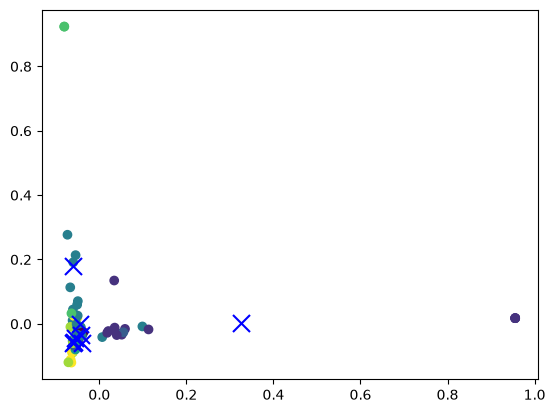

In [12]:
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=model.predict(X))
plt.scatter(reduced_cluster_centers[:, 0], reduced_cluster_centers[:, 1], marker='x', s=150, c='b')